**Task** **3** : **Handwritten** **Charcter** **Recognition**

In [ ]:
# Task 3 : HANDWRITTEN CHARACTER RECOGNITION
# Import Library

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

**Use** **Mnist** **Dataset**

In [ ]:
# Load Mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


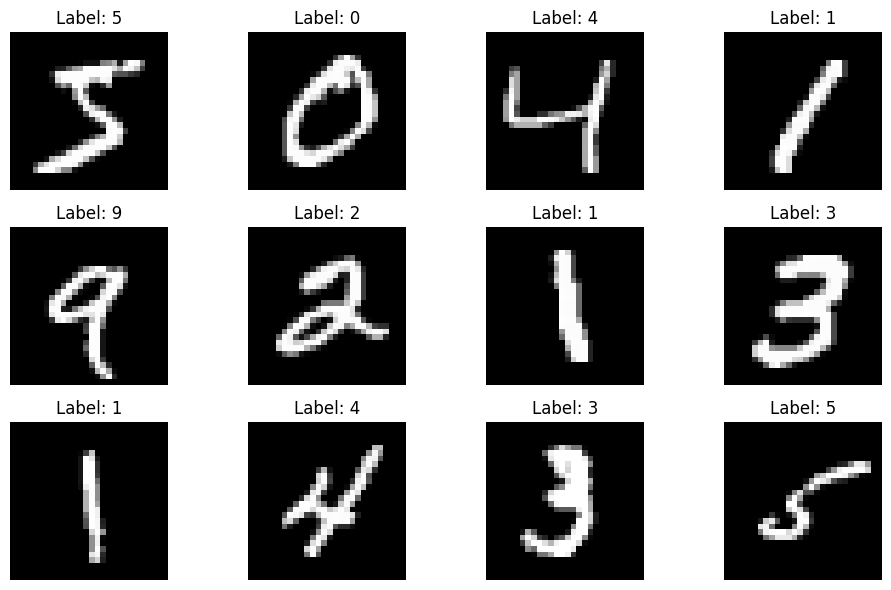

In [ ]:
# Display Image

plt.figure(figsize=(10,6))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_train[i],
        cmap='gray'
    )

    plt.title(
        f"Label: {y_train[i]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [ ]:
# Normalize

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
# Reshape
X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

print(X_train.shape)

(60000, 28, 28, 1)


In [ ]:
# Encode Label

y_train_cat = to_categorical(
    y_train,
    10
)

y_test_cat = to_categorical(
    y_test,
    10
)

In [ ]:
# Build CNN

cnn_model = Sequential([

    Conv2D(
        32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Conv2D(
        64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(
        pool_size=(2,2)
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        10,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile ,Train

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train,
    y_train_cat,

    validation_split=0.10,

    epochs=2,

    batch_size=128
)

Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.9211 - loss: 0.2602 - val_accuracy: 0.9847 - val_loss: 0.0553
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - accuracy: 0.9766 - loss: 0.0774 - val_accuracy: 0.9882 - val_loss: 0.0408


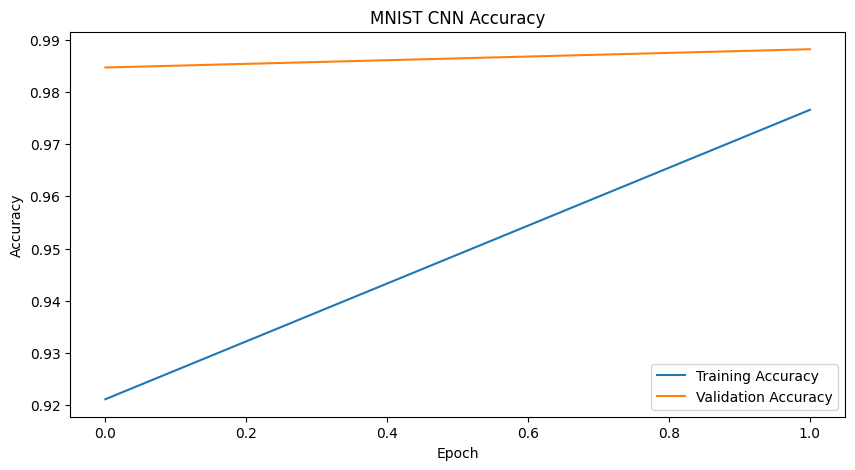

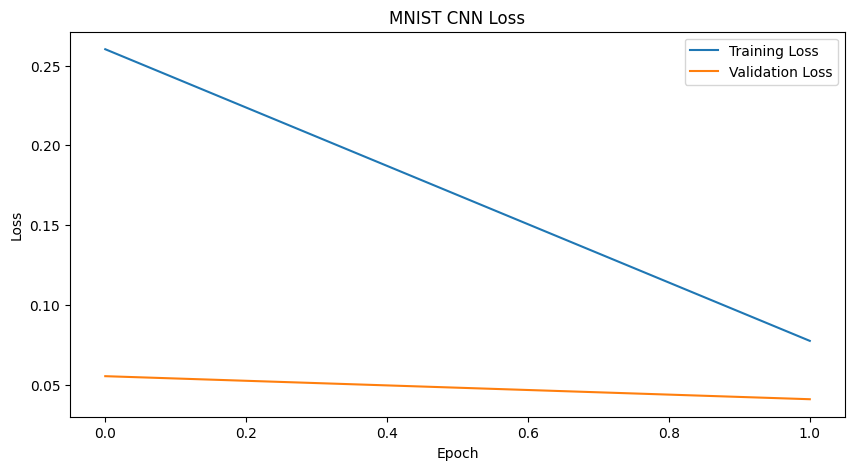

In [ ]:
# Accuracy And Loss Graph

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MNIST CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("MNIST CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
# Evaluate

test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test_cat
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9870 - loss: 0.0387
Test Accuracy: 0.9869999885559082


In [ ]:
# Predict

predictions = cnn_model.predict(
    X_test
)

y_pred = np.argmax(
    predictions,
    axis=1
)

print(y_pred[:20])
print(y_test[:20])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [ ]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



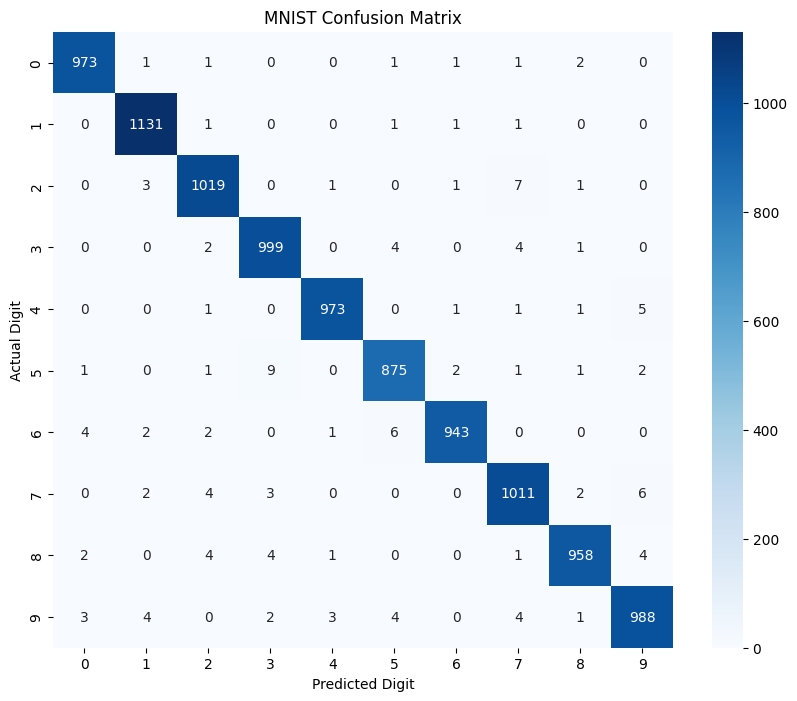

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

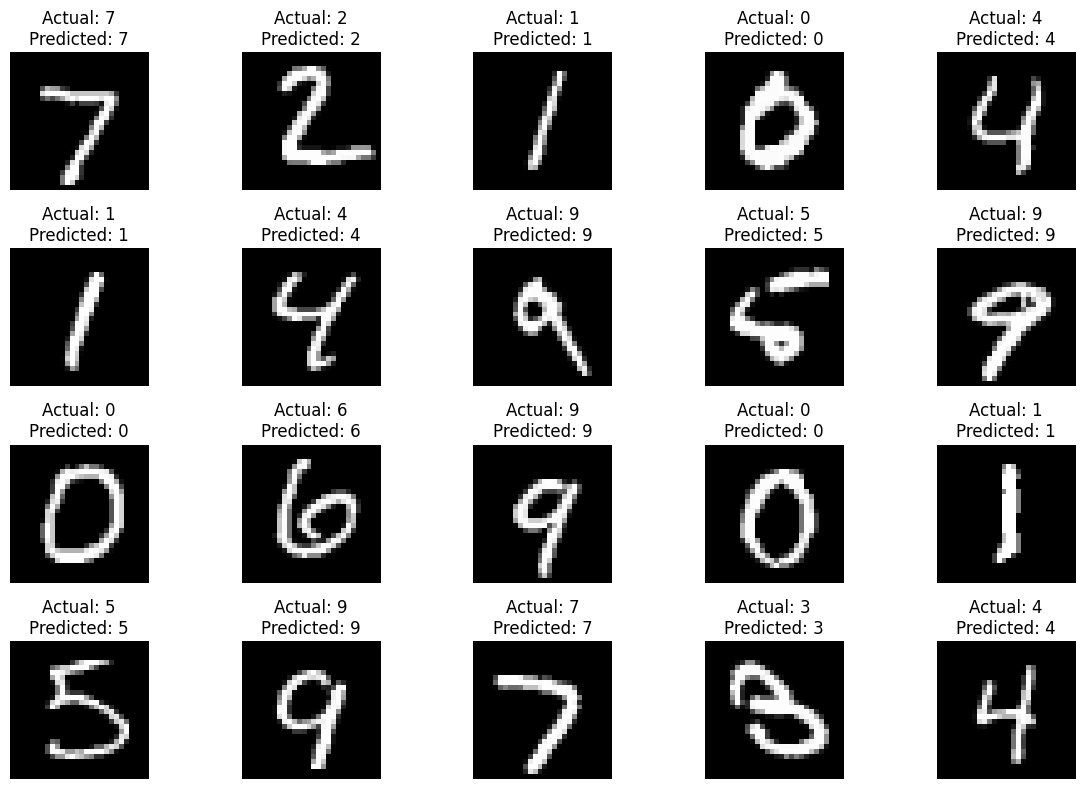

In [ ]:
# Display Predictions

plt.figure(figsize=(12,8))

for i in range(20):

    plt.subplot(4,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {y_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


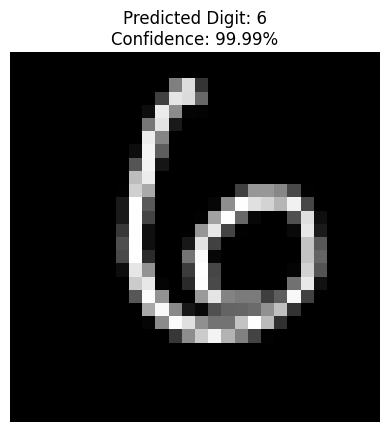

In [ ]:
# Predict One Hand Written

index = 100

image = X_test[index]

prediction = cnn_model.predict(
    image.reshape(1,28,28,1)
)

digit = np.argmax(prediction)

confidence = np.max(prediction)

plt.imshow(
    image.reshape(28,28),
    cmap='gray'
)

plt.title(
    f"Predicted Digit: {digit}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis('off')

plt.show()

In [ ]:
# Save Model

cnn_model.save(
    "handwritten_character_model.h5"
)

print("Model saved successfully.")

Model saved successfully.


**Use** **Emnist** **Dataset**

In [ ]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 1.6 MB/s eta 0:00:00


In [ ]:
# Import Emnist Dataset

import torch
from torchvision import transforms

from medmnist import INFO
from medmnist.dataset import PathMNIST

In [ ]:
# Download Emnist

!wget -q https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip

In [ ]:
# Extract

!unzip -q gzip.zip -d emnist_data

In [ ]:
!find emnist_data -type f | head -20

emnist_data/gzip/emnist-balanced-test-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-letters-train-images-idx3-ubyte.gz
emnist_data/gzip/emnist-letters-test-images-idx3-ubyte.gz
emnist_data/gzip/emnist-mnist-test-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-byclass-train-images-idx3-ubyte.gz
emnist_data/gzip/emnist-byclass-train-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-digits-train-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-balanced-train-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-mnist-train-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-mnist-train-images-idx3-ubyte.gz
emnist_data/gzip/emnist-balanced-train-images-idx3-ubyte.gz
emnist_data/gzip/emnist-balanced-mapping.txt
emnist_data/gzip/emnist-balanced-test-images-idx3-ubyte.gz
emnist_data/gzip/emnist-bymerge-train-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-bymerge-test-labels-idx1-ubyte.gz
emnist_data/gzip/emnist-bymerge-test-images-idx3-ubyte.gz
emnist_data/gzip/emnist-mnist-mapping.txt
emnist_data/gzip/emnist-byclass-mappi

In [ ]:
# We'll use idx2numpy to convert the files.

!pip install -q idx2numpy

  Preparing metadata (setup.py) ... done


In [ ]:
import idx2numpy
import gzip
import os

In [ ]:
# Locate Emnist Files

!find /content/emnist_data -type f | grep -i balanced

/content/emnist_data/gzip/emnist-balanced-test-labels-idx1-ubyte.gz
/content/emnist_data/gzip/emnist-balanced-train-labels-idx1-ubyte.gz
/content/emnist_data/gzip/emnist-balanced-train-images-idx3-ubyte.gz
/content/emnist_data/gzip/emnist-balanced-mapping.txt
/content/emnist_data/gzip/emnist-balanced-test-images-idx3-ubyte.gz


In [ ]:
# Load Images of Emnist

train_images_path = (
    "/content/emnist_data/gzip/"
    "emnist-balanced-train-images-idx3-ubyte.gz"
)

train_labels_path = (
    "/content/emnist_data/gzip/"
    "emnist-balanced-train-labels-idx1-ubyte.gz"
)

test_images_path = (
    "/content/emnist_data/gzip/"
    "emnist-balanced-test-images-idx3-ubyte.gz"
)

test_labels_path = (
    "/content/emnist_data/gzip/"
    "emnist-balanced-test-labels-idx1-ubyte.gz"
)

In [ ]:
with gzip.open(train_images_path, 'rb') as f:
    X_train_emnist = idx2numpy.convert_from_file(f)

with gzip.open(train_labels_path, 'rb') as f:
    y_train_emnist = idx2numpy.convert_from_file(f)

with gzip.open(test_images_path, 'rb') as f:
    X_test_emnist = idx2numpy.convert_from_file(f)

with gzip.open(test_labels_path, 'rb') as f:
    y_test_emnist = idx2numpy.convert_from_file(f)

In [ ]:
# Check Emnist Shape

print(
    "Training images:",
    X_train_emnist.shape
)

print(
    "Training labels:",
    y_train_emnist.shape
)

print(
    "Testing images:",
    X_test_emnist.shape
)

print(
    "Testing labels:",
    y_test_emnist.shape
)

Training images: (112800, 28, 28)
Training labels: (112800,)
Testing images: (18800, 28, 28)
Testing labels: (18800,)


In [ ]:
# Import Emnist Orientation Fix

def fix_emnist_image(image):

    image = np.transpose(
        image
    )

    image = np.fliplr(
        image
    )

    return image

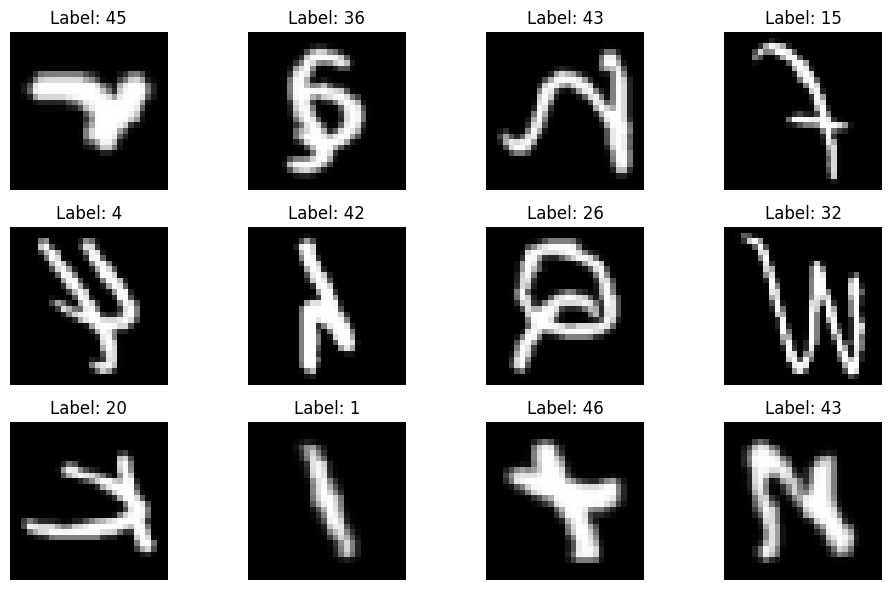

In [ ]:
# Test

plt.figure(figsize=(10, 6))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    image = fix_emnist_image(
        X_train_emnist[i]
    )

    plt.imshow(
        image,
        cmap='gray'
    )

    plt.title(
        f"Label: {y_train_emnist[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Normalize Emnist

X_train_emnist = (
    X_train_emnist.astype('float32')
    / 255.0
)

X_test_emnist = (
    X_test_emnist.astype('float32')
    / 255.0
)

In [ ]:
# Reshape

X_train_emnist = X_train_emnist.reshape(
    -1,
    28,
    28,
    1
)

X_test_emnist = X_test_emnist.reshape(
    -1,
    28,
    28,
    1
)

print(
    X_train_emnist.shape
)

print(
    X_test_emnist.shape
)

(112800, 28, 28, 1)
(18800, 28, 28, 1)


In [ ]:
# check Number of class

num_emnist_classes = len(
    np.unique(y_train_emnist)
)

print(
    "Number of EMNIST classes:",
    num_emnist_classes
)

Number of EMNIST classes: 47


In [ ]:
# One Hot Encode Emnist Labels

y_train_emnist_cat = to_categorical(
    y_train_emnist,
    num_emnist_classes
)

y_test_emnist_cat = to_categorical(
    y_test_emnist,
    num_emnist_classes
)

In [ ]:
# CNN Model

emnist_model = Sequential([

    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        (2, 2)
    ),

    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(
        (2, 2)
    ),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        num_emnist_classes,
        activation='softmax'
    )
])

emnist_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,159 (539.68 KB)

 Trainable params: 137,967 (538.93 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Compile Model

emnist_model.compile(
    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
# Train Emnist CNN

emnist_history = emnist_model.fit(

    X_train_emnist,

    y_train_emnist_cat,

    validation_split=0.10,

    epochs=3,

    batch_size=128
)

Epoch 1/3
794/794 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.7402 - loss: 0.7976 - val_accuracy: 0.8105 - val_loss: 0.5387
Epoch 2/3
794/794 ━━━━━━━━━━━━━━━━━━━━ 71s 89ms/step - accuracy: 0.8145 - loss: 0.5458 - val_accuracy: 0.8254 - val_loss: 0.4969
Epoch 3/3
794/794 ━━━━━━━━━━━━━━━━━━━━ 70s 88ms/step - accuracy: 0.8305 - loss: 0.4827 - val_accuracy: 0.8278 - val_loss: 0.4868


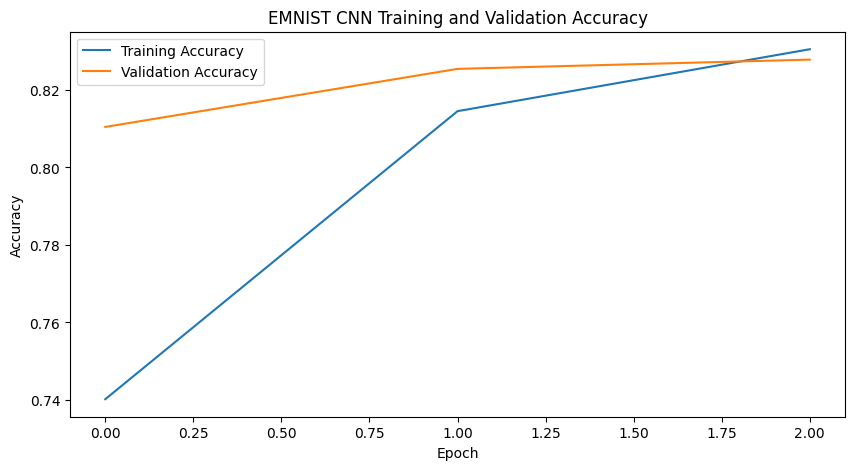

In [ ]:
# Accuracy Graph

plt.figure(figsize=(10, 5))

plt.plot(
    emnist_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    emnist_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    "EMNIST CNN Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

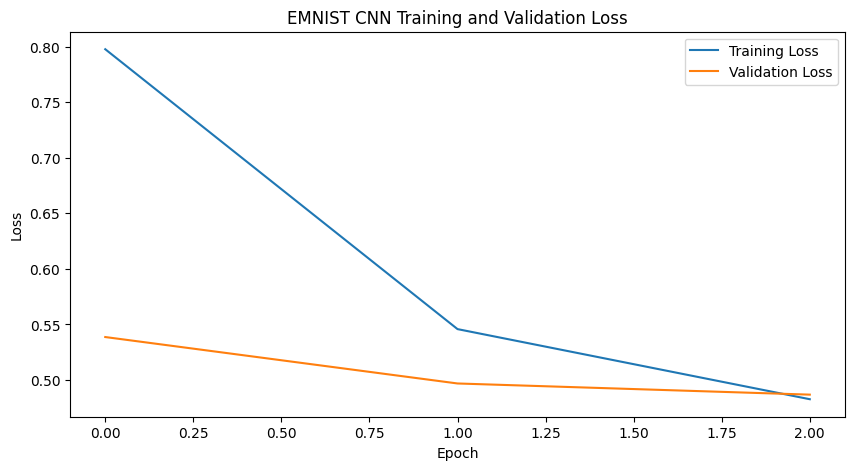

In [ ]:
# Loss Graph

plt.figure(figsize=(10, 5))

plt.plot(
    emnist_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    emnist_history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    "EMNIST CNN Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# Evaluate

emnist_loss, emnist_accuracy = emnist_model.evaluate(

    X_test_emnist,

    y_test_emnist_cat
)

print(
    "EMNIST Test Accuracy:",
    emnist_accuracy
)

588/588 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8302 - loss: 0.4969
EMNIST Test Accuracy: 0.8302127718925476


In [ ]:
# Prediction

emnist_predictions = emnist_model.predict(
    X_test_emnist
)

emnist_pred = np.argmax(
    emnist_predictions,
    axis=1
)

588/588 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step


In [ ]:
# Classification Report

print(
    classification_report(
        y_test_emnist,
        emnist_pred
    )
)

              precision    recall  f1-score   support

           0       0.52      0.87      0.65       400
           1       0.55      0.63      0.59       400
           2       0.90      0.77      0.83       400
           3       0.97      0.98      0.97       400
           4       0.93      0.84      0.88       400
           5       0.86      0.88      0.87       400
           6       0.88      0.93      0.90       400
           7       0.87      0.96      0.91       400
           8       0.87      0.93      0.90       400
           9       0.63      0.82      0.71       400
          10       0.96      0.85      0.90       400
          11       0.93      0.88      0.90       400
          12       0.89      0.93      0.91       400
          13       0.93      0.78      0.85       400
          14       0.92      0.90      0.91       400
          15       0.67      0.38      0.49       400
          16       0.85      0.93      0.89       400
          17       0.94    

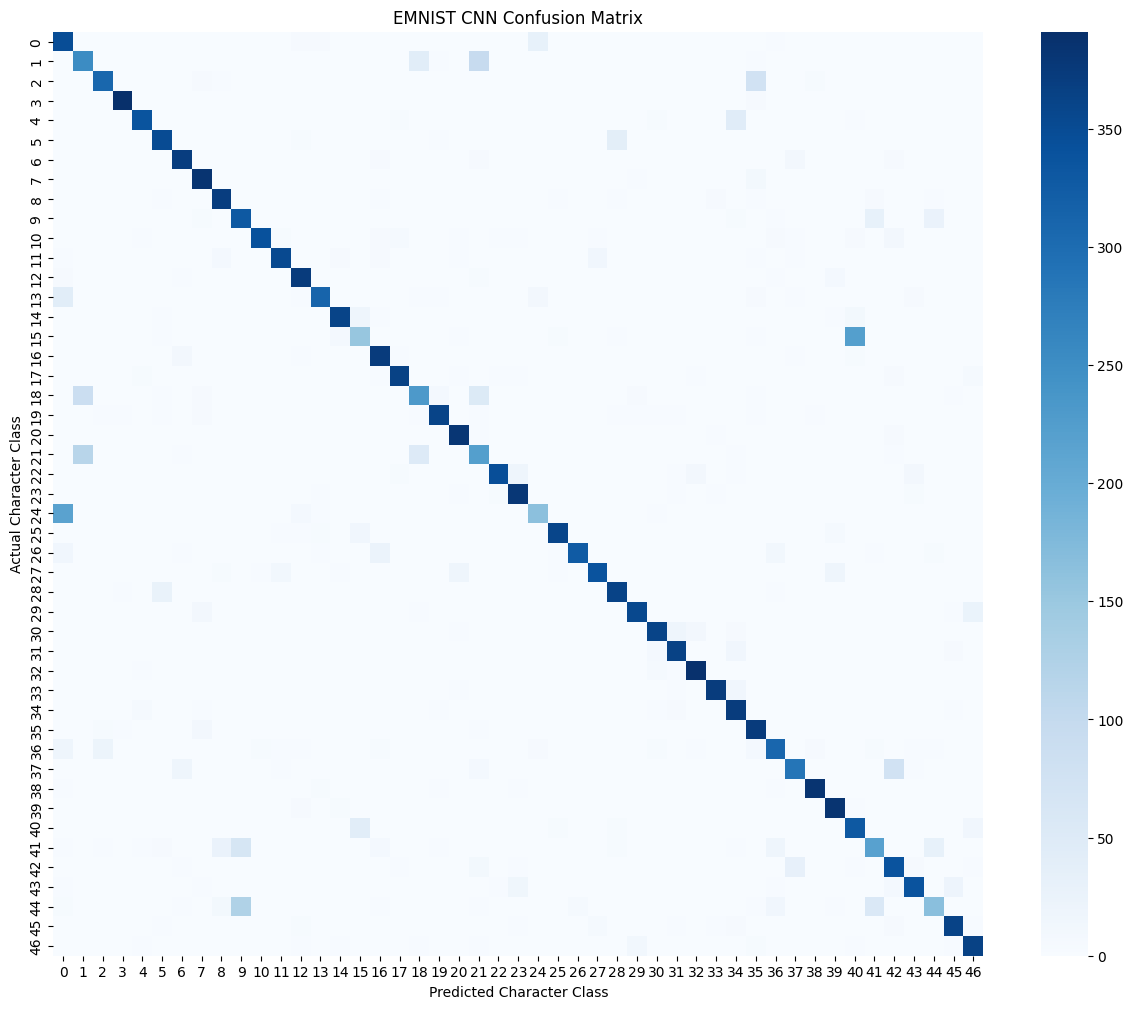

In [ ]:
# Confusion Matrix

emnist_cm = confusion_matrix(
    y_test_emnist,
    emnist_pred
)

plt.figure(figsize=(15, 12))

sns.heatmap(
    emnist_cm,
    cmap='Blues'
)

plt.title(
    "EMNIST CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Character Class"
)

plt.ylabel(
    "Actual Character Class"
)

plt.show()

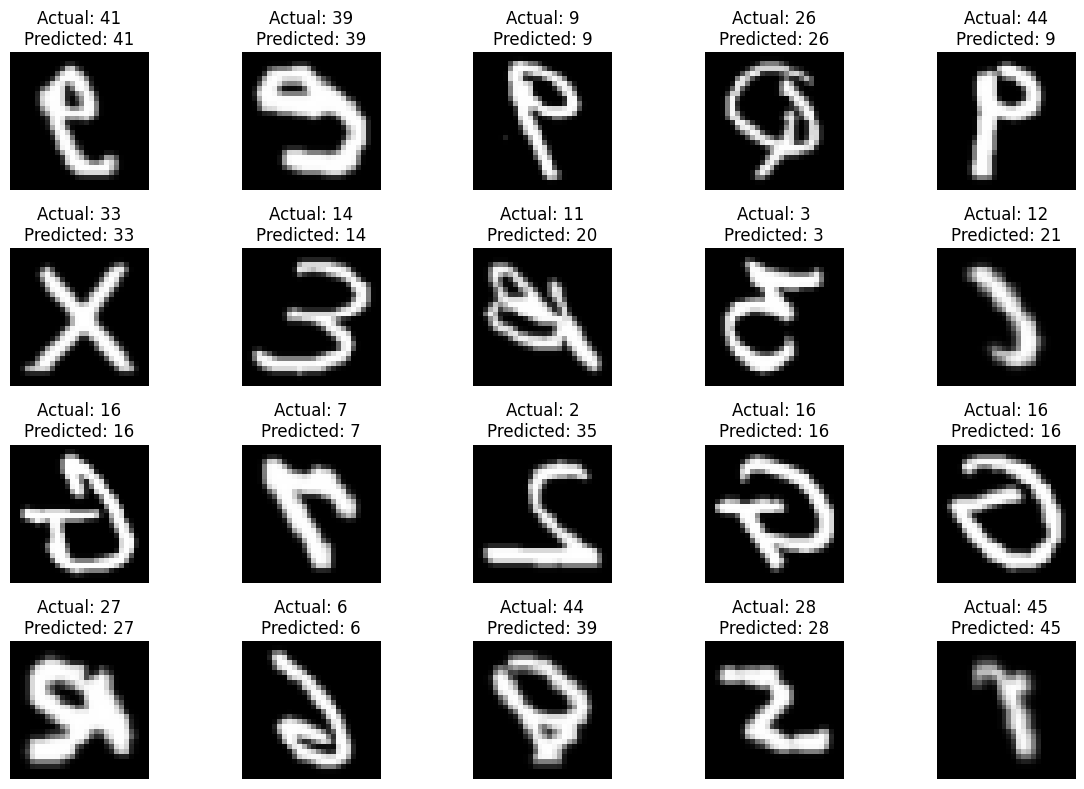

In [ ]:
# Display Emnist Prediction

plt.figure(figsize=(12, 8))

for i in range(20):

    plt.subplot(4, 5, i + 1)

    image = fix_emnist_image(
        X_test_emnist[i].reshape(28, 28)
    )

    plt.imshow(
        image,
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test_emnist[i]}\n"
        f"Predicted: {emnist_pred[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Save Model

emnist_model.save(
    "EMNIST_CNN_Model.keras"
)

print(
    "EMNIST model saved successfully!"
)

EMNIST model saved successfully!


**Compare** **Mnist** **And** **Emnist**

In [ ]:
comparison = pd.DataFrame({

    'Dataset': [
        'MNIST',
        'EMNIST'
    ],

    'Task': [
        'Handwritten Digit Recognition',
        'Handwritten Character Recognition'
    ],

    'Test Accuracy': [
        test_accuracy,
        emnist_accuracy
    ]
})

display(
    comparison
)

,Dataset,Task,Test Accuracy
0,MNIST,Handwritten Digit Recognition,0.987000
1,EMNIST,Handwritten Character Recognition,0.830213


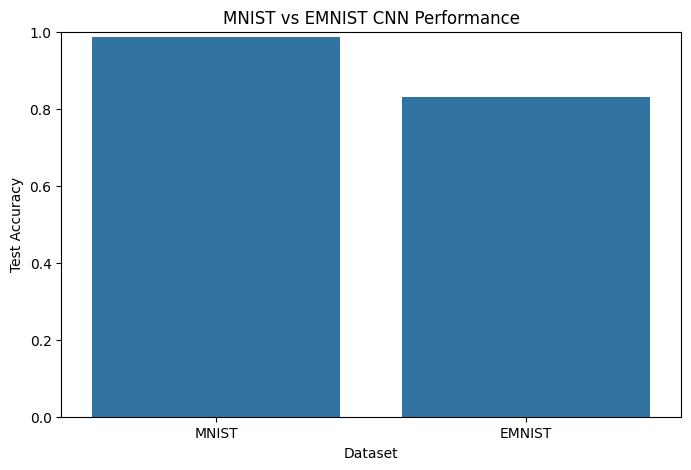

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Dataset',
    y='Test Accuracy'
)

plt.title(
    "MNIST vs EMNIST CNN Performance"
)

plt.ylim(0, 1)

plt.show()

**Steps Performed**

**Step 1: Dataset Collection**

we used two image-based handwritten recognition datasets:

MNIST – used for recognizing handwritten digits from 0 to 9.

EMNIST – used for recognizing handwritten characters/digits from the EMNIST dataset.

The purpose was to build a deep learning model that can identify handwritten information from an input image.

**Step 2: Data Understanding**

The datasets contain grayscale handwritten images.

Each image contains pixel values representing the handwritten digit or character.

The images were examined to understand:

Image dimensions
Number of training and testing images
Number of classes
Pixel-value range
Distribution of classes

The handwritten images were also visualized to understand what the model receives as input.

**Step 3: Image Preprocessing**

Before training the deep learning model, the images were preprocessed.

The main preprocessing steps were:

Converting images into numerical arrays
Normalizing pixel values
Reshaping images according to the CNN input format
Preparing the corresponding labels

Pixel values originally range approximately from:

0 to 255

They were normalized to:

0 to 1

using:

X = X.astype("float32") / 255.0

This helps the neural network train more efficiently.

**Step 4: Preparing Images for CNN**

The images were converted into the required CNN format.

For grayscale images, a single channel was added.

The general format becomes:

Samples × Height × Width × 1

For MNIST, for example:

60000 × 28 × 28 × 1

The final 1 represents the grayscale channel.

**Step 5: Label Preparation**

The image labels represent the actual digit or character contained in each image.

For MNIST, the classes represent:

0, 1, 2, 3, 4, 5, 6, 7, 8, 9

The labels were converted into a format suitable for multi-class classification using one-hot encoding.

**Step 6: Train-Test Split**

The datasets were divided into training and testing data.

The training data was used to teach the model how to recognize handwritten patterns.

The testing data was kept separate and used to evaluate the model on images that it had not seen during training.

The general workflow was:

Training Images → Model Training
Testing Images  → Model Evaluation

**Step 7: CNN Model Development**

A Convolutional Neural Network (CNN) was used for handwritten digit and character recognition.

The CNN contains layers such as:

Convolutional layers – detect important image patterns such as edges and shapes.

ReLU activation – introduces non-linearity.

Max Pooling – reduces the size of feature maps while retaining important information.

Flatten layer – converts the extracted features into a one-dimensional representation.

Dense layers – perform classification.

Softmax output layer – produces probabilities for the different classes.

**Step 8: Model Training**

The CNN was trained using the handwritten images and their corresponding labels.

During training, the model learns different patterns.

For example, in MNIST, it gradually learns how the shapes and pixel patterns correspond to digits such as:

0 → circular pattern

1 → vertical pattern

2 → curved/diagonal pattern
...

9 → different curved and loop patterns

For EMNIST, the model learns more complex patterns required to distinguish handwritten characters and digits.

**Step 9: Training and Validation Performance**

During training, the model's performance was monitored using:

Training accuracy
Validation accuracy
Training loss
Validation loss

Accuracy and loss graphs were plotted to understand how the model learned over the training epochs.

These graphs also help identify problems such as underfitting or overfitting.

**Step 10: Model Evaluation**

After training, the model was evaluated using the test datasets.

The main evaluation measures included:

Test Accuracy
Loss
Classification Report
Confusion Matrix

The confusion matrix helps identify which digits or characters were correctly recognized and which ones were confused with other classes.

**Step 11: Prediction**

After the model was trained, it was used to predict the class of an unseen handwritten image.

The prediction process is:

Input Handwritten Image
          ↓
Image Preprocessing
          ↓
Pixel Normalization
          ↓
CNN Model
          ↓
Class Probabilities
          ↓
Highest Probability
          ↓
Predicted Digit/Character

For example:

Input Image
     ↓
    CNN
     ↓
0 → 1%
1 → 2%
2 → 4%
3 → 88%
4 → 1%
...
     ↓
Predicted Class = 3

The model therefore predicts the class having the highest probability.

**Step 12: MNIST Prediction**

For MNIST, the trained model predicts one of the ten handwritten digits:

0  1  2  3  4  5  6  7  8  9

For example:

Input → handwritten image of 7

Prediction → 7
Confidence → model's highest probability

**Step 13: EMNIST Prediction**

For EMNIST, the trained model predicts the appropriate class from the particular EMNIST split being used.

The input image is first resized/preprocessed according to the model's requirements and then passed through the CNN.

The model returns the predicted character/digit and its corresponding probability.

**Step 14: Comparison of MNIST and EMNIST**
Feature	MNIST	EMNIST
Data Type	Handwritten digits	Handwritten characters/digits
Image Type	Grayscale	Grayscale
Image Size	28 × 28	28 × 28
Main Task	Digit Recognition	Character/Digit Recognition
Model	CNN	CNN
Feature	Pixel values	Pixel values
Output	Digit class	Character/digit class

**Step 15: Overall Working of Task **

The complete system can be represented as:

             MNIST / EMNIST
                    ↓
             Image Collection
                    ↓
             Image Preprocessing
                    ↓
          Pixel Normalization (0–1)
                    ↓
              CNN Model
                    ↓
             Feature Extraction
                    ↓
               Classification
                    ↓
          Predicted Digit/Character
                    ↓
        Accuracy + Confusion Matrix

Conclusion :

We successfully developed a Handwritten Digit and Character Recognition system using the MNIST and EMNIST datasets. The project started by loading and understanding handwritten grayscale images and their corresponding labels. The images were then preprocessed by converting them into numerical arrays, normalizing pixel values, and reshaping them into the required format for the CNN model.

A Convolutional Neural Network (CNN) was trained to learn important visual patterns such as edges, curves, shapes, and other features from handwritten images. The model was evaluated using accuracy, loss, classification reports, and confusion matrices to measure its recognition performance.

The trained model was then used to predict previously unseen handwritten images. For each input image, the CNN analyzes the pixel patterns, calculates probabilities for the available classes, and selects the class with the highest probability as the final prediction.

Overall, this task helped us understand the complete workflow of image-based deep learning, including image preprocessing, normalization, CNN architecture, model training, evaluation, and prediction. By using both MNIST and EMNIST, we demonstrated how CNNs can be applied not only to handwritten digit recognition but also to more complex handwritten character recognition problems.